## 다양한 분류 알고리즘
- 종류: 로지스틱 회귀와 확률적 경사 하강법
---
# 1. 로지스틱 회귀
-이름에 회귀라고 되어 있지만 실제로는 분류 알고리즘입니다.

-분류 모델에서 어떤 샘플에 대해서 예측하는지를 확률로 표현합니다.

## 럭키백의 확률

- 7개의 생선의 종류가 럭키백에 들어갈 예정입니다.

- 럭키백에 들어갈 생선의 길이, 높이, 대각선 길이, 무게, 두께를 제공합니다.

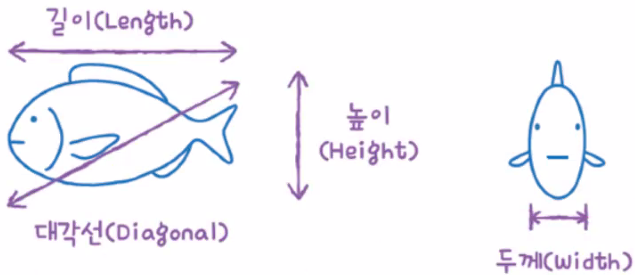

### 데이터 준비하기

In [1]:
import pandas as pd

fish = pd.read_csv('data/fish.csv')

fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [2]:
print(pd.unique(fish['Species']))

<StringArray>
['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
Length: 7, dtype: str


In [3]:
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()

In [4]:
print(fish_input[:5])

[[242.      25.4     30.      11.52     4.02  ]
 [290.      26.3     31.2     12.48     4.3056]
 [340.      26.5     31.1     12.3778   4.6961]
 [363.      29.      33.5     12.73     4.4555]
 [430.      29.      34.      12.444    5.134 ]]


In [5]:
fish_target = fish['Species'].to_numpy()

In [6]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42)

In [7]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

ss.fit(train_input)

train_scaled = ss.transform(train_input)

test_scaled = ss.transform(test_input)

### k-최근접 이웃 분류기의 확률 예측

In [8]:
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier(n_neighbors=3)

kn.fit(train_scaled, train_target)

print(kn.score(train_scaled, train_target))
print(kn.score(test_scaled, test_target))

0.8907563025210085
0.85


In [9]:
print(kn.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [10]:
print(test_scaled[:5])

print(kn.predict(test_scaled[:5]))

[[-0.88741352 -0.91804565 -1.03098914 -0.90464451 -0.80762518]
 [-1.06924656 -1.50842035 -1.54345461 -1.58849582 -1.93803151]
 [-0.54401367  0.35641402  0.30663259 -0.8135697  -0.65388895]
 [-0.34698097 -0.23396068 -0.22320459 -0.11905019 -0.12233464]
 [-0.68475132 -0.51509149 -0.58801052 -0.8998784  -0.50124996]]
['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']


In [11]:
import numpy as np

proba = kn.predict_proba(test_scaled[:5])

print(np.round(proba, decimals=4))

[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']

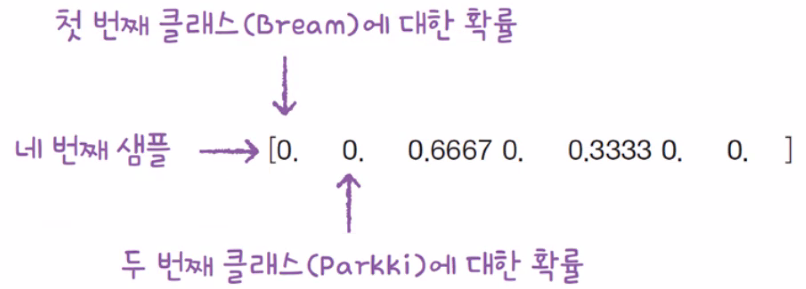

In [12]:
print(test_scaled[3:4])

distances, indexes = kn.kneighbors(test_scaled[3:4])
print(train_target[indexes])

[[-0.34698097 -0.23396068 -0.22320459 -0.11905019 -0.12233464]]
[['Roach' 'Perch' 'Perch']]


### KNN에서 확률 계산 방식

- `KNeighborsClassifier(n_neighbors=3)` → 최근접 이웃 3개를 기준으로 분류
- 예를 들어 클래스가 2개(A, B)이고, 특정 샘플의 3개 이웃 중
    - 2개가 A, 1개가 B라면
    - `predict_proba()` = `[P(A)=2/3, P(B)=1/3]`
- 즉, **확률이 할상 0, 1/3, 2/3, 1** 같이 KNN의 확률은 이웃 수($K$)에 대한 상대 빈도로 계산되기 때문에, 항상 $1/K$ 단위를 간격으로 하는 이산적인(Discrete) 값으로만 나타납니다.

문제점:

- KNN의 확률은 모델이 확률 분포를 학습해 추론(inferece) 한 결과가 아니라, 주변 이웃 클래스의 상대 빈도로 계산됩니다. 따라서 데이터의 밀도 차이, 거리 차이를 연속적으로 반영하지 못하고, 확률 값이 1/K 단위로만 변하는 이산적(discrete) 분포를 가집니다.
- 이로 인해 모델 출력이 확률처럼 부드럽게(calibrated) 해석되기 어렵습니다.

---

로지스틱 회귀는 분류 모델로 이 알고리즘은 선형 회귀와 동일하게 선형 방정식을 학습합니다.

- z = a × (Weight) + b × (Length) + c × (Diagonal) + d × (Height) + e × (Width) + f

- a, b, c, d, e는 가중치 혹은 계수

- 특성은 늘어났지만 선형 방정식 입니다.

- z는 어떤 값도 가능하지만 확률이 되려면 0~1 (또는 0~100%) 사이의 값이 되어야 합니다.

- 시그모이드 함수(sigmoid function) 또는 로지스틱 함수(logistic function)를 사용하여 z가 아주 큰 음수 일 때 0이 되고, z가 아주 큰 양수일 때 1이 되도록 바꿀 수 있습니다.

    - 시그모이드 함수와 그래프

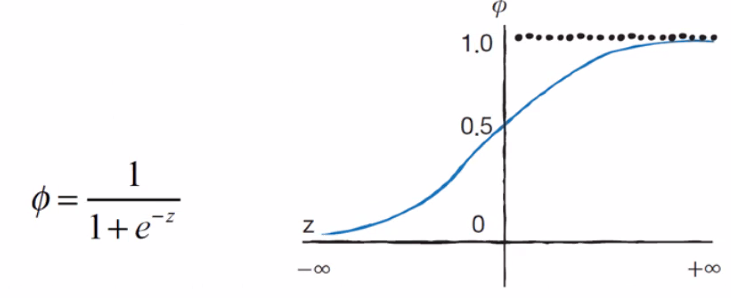

---

## 넘파이를 이용한 시그모이드 그래프 작성

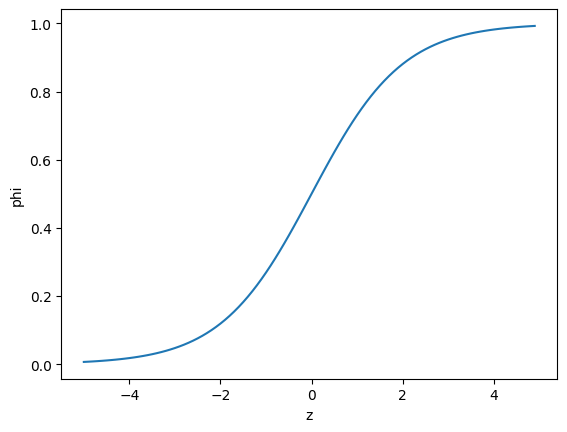

In [13]:
import numpy as np
import matplotlib.pyplot as plt

z = np.arange(-5, 5, 0.1)
phi = 1 / (1 + np.exp(-z))

plt.plot(z, phi)
plt.xlabel('z')
plt.ylabel('phi')
plt.show()

 ---
### 로지스틱 회귀로 이진 분류 수행하기

In [14]:
char_arr = np.array(['A', 'B', 'C', 'D', 'E'])
print(char_arr[[True, False, True, False, False]])

['A' 'C']


In [15]:
bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')
print(bream_smelt_indexes)

[ True False  True False False False False  True False False False  True
 False False False  True  True False False  True False  True False False
 False  True False False  True False False False False  True False False
  True  True False False False False False  True False False False False
 False  True False  True False False  True False False False  True False
 False False False False False  True False  True False False False False
 False False False False False  True False  True False False  True  True
 False False False  True False False False False False  True False False
 False  True False  True False False  True  True False False False False
 False False False False  True  True False False  True False False]


In [16]:
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]

In [17]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
print(lr.predict(train_bream_smelt[:5]))

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


 ---
이진 분류는 데이터를 두 개의 클래스 중 하나로 구분하는 문제입니다.

이 때 양성 클래스 (Positive Class)는 우리가 관심을 두는 대상으로 보통 1로 표현됩니다.

양성 클래스가 아닌 나머지는 음성 클래스 (Negative Class)이고 보통 0으로 표현됩니다.

In [19]:
print(lr.predict_proba(train_bream_smelt[:5])) # sigmoid function

[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]


첫번째 열이 음성 클래스(0)에 대한 확률이고 두번째 열이 양성 클래스(1)에 대한 확률입니다.

---

In [20]:
print(lr.classes_)

['Bream' 'Smelt']


In [21]:
print(lr.coef_, lr.intercept_)

[[-0.40451732 -0.57582787 -0.66248158 -1.01329614 -0.73123131]] [-2.16172774]


 ---
z = -0.405 × (Weight) - 0.576 × (Length) - 0.662 × (Diagonal) - 1.013 × (Height) - 0.731 × (Width) - 2.161
- 결과값 z에 따른 분류 기준

    | **z 값** | **분류 결과** | **의미** |
    | :--- | :--- | :--- |
    | **z > 0** | **양성 클래스 (Positive, 1)** | 양성 클래스 쪽에 위치 |
    | **z < 0** | **음성 클래스 (Negative, 0)** | 음성 클래스 쪽에 위치 |
    | **z = 0** | 결정 경계 | 두 클래스의 경계선 |

In [22]:
decisions = lr.decision_function(train_bream_smelt[:5])
print(decisions)

[-6.02991358  3.57043428 -5.26630496 -4.24382314 -6.06135688]


In [23]:
from scipy.special import expit

# expit()은 시그모이드 함수
# z값을 0~1 값으로 변환
# 양성 클래스 확률만 출력

print(expit(decisions))

[0.00239993 0.97262675 0.00513614 0.01414953 0.00232581]


 ---
### 로지스틱 회귀로 다중 분류 수행하기

In [24]:
# C는 규제(regularization) 세기 조절 값으로 기본은 1입니다.
# 값이 클수록 규제가 약해지고 모델이 데이터에 더 잘 맞추고
# 값이 작을수록 규제가 강해지고, 모델이 단순해집니다.
# 규제를 조금 완화하기 위해 20으로 설정합니다.

# 로지스틱 회귀는 정답을 여러번 반복해서 최적의 가중치를 찾는 방식입니다.
# 데이터가 복잡하면 100번으로는 수렴하지 않아 오류날수 있어 1000번으로 늘립니다.
# max_iter=1000
lr = LogisticRegression(C=20, max_iter=1000)

lr.fit(train_scaled, train_target)

print(lr.score(train_scaled, train_target))

print(lr.score(test_scaled, test_target))

0.9327731092436975
0.925


In [25]:
print(lr.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']


 ---
기울기(가중치)와 절편 구하기

In [26]:
print(lr.coef_, lr.intercept_)
print(lr.classes_)

[[-1.50605455 -1.03747913  2.60919713  7.69422739 -1.18603342]
 [ 0.19200047 -1.99988812 -3.79617725  6.50312639 -2.00022754]
 [ 3.55793539  6.36988929 -8.52233732 -5.75397233  3.79233438]
 [-0.11453308  3.61060121  3.94464503 -3.62243904 -1.7598168 ]
 [-1.40843717 -6.09242191  5.28629633 -0.86696569  1.84518455]
 [-1.33419952  1.48153392  1.38217547 -5.6602348  -4.39228963]
 [ 0.61328846 -2.33223527 -0.90379939  1.70625807  3.70084846]] [-0.10345045 -0.27281217  3.24444852 -0.17565069  2.64960025 -6.72042852
  1.37829306]
['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


 ---
# 점수 구하기

첫 번째 클래스 점수 = $(-1.506)x_1 + (-1.037)x_2 + (2.609)x_3 + (7.694)x_4 + (-1.186)x_5 + (-0.103)$

두 번째 클래스 점수 = $(0.192)x_1 + (-1.999)x_2 + (-3.796)x_3 + (6.503)x_4 + (-2.000)x_5 + (-0.272)$

- 반복해서 총 7개의 클래스 점수를 계산합니다.

- $x_1, x_2, ..., x_5$는 테스트 샘플 입력 특성 값입ㄴ디ㅏ.

### logit (결정 점수)

- 위에서 계산한 **각 클래스의 점수**는 **logit(로짓)** 이라고 부릅니다.
- logit은 각 클래스에 대해 모델이 계산한  
**가중치 합 + 절편 형태의 원시 점수**로, 아직 확률로 변환되기 전의 값입니다.
- logit 값은 음수나 양수가 될 수 있으며, 값의 크기는 **해당 클래스 쪽으로 얼마나 강하게 기울어져 있는지**를 의미합니다.

#### decision_function()은 점수이고, predict_proba()는 확률입니다.

In [27]:
decision = lr.decision_function(test_scaled[:5])
print(np.round(decision, decimals=2))

[[ -6.51   1.04   5.17  -2.76   3.34   0.35  -0.63]
 [-10.88   1.94   4.78  -2.42   2.99   7.84  -4.25]
 [ -4.34  -6.24   3.17   6.48   2.36   2.43  -3.87]
 [ -0.69   0.45   2.64  -1.21   3.26  -5.7    1.26]
 [ -6.4   -1.99   5.82  -0.13   3.5   -0.09  -0.7 ]]


In [28]:
proba = lr.predict_proba(test_scaled[:5]) # decision_function으로 점수를 구하고 softmax로 확률 계산
print(np.round(proba, decimals=3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


## 소프트맥스(Softmax) 함수 원리

소프트맥스 함수는 여러 개의 선택지(다중 분류) 중 하나를 고를 때, 각 클래스에 대한 모델의 점수를 확률(0~1 사이, 총합은 1)로 변환해 주는 함수입니다.

### 1. 소프트맥스 수식

- $P_i = \frac{e^{z_i}}{\sum^K_{j=1}{e^{z_j}}}$

- $z_i$: 특정 클래스 $i$에 대해 모델이 출력한 원시 점수(logit)

- $e^{z_i}$: 점수를 지수화하여 항상 **양수**로 만들고, 점수 차이를 더 강조함

- $\sum{e^{z_j}}$: 모든 클래스의 지수 값을 더한 **총합 (분모)**

- K : 전체 클래스 개수

---

### 2. 계산 과정 (예: 클래스 A, B, C의 점수가 [2.0, 1.0, 0.1]일 때)

| **단계** | **계산 내용** | **결과 (예시)** |
| :--- | :--- | :--- |
| **1단계: 지수화** | 각 점수 $z$를 $e$의 거듭제곱으로 변환 | $e^{2.0} \approx 7.39, e^{1.0} \approx 2.72, e^{0.1} \approx 1.11$ |
| **2단계: 총합 구하기** | 변환된 모든 지수 값을 더함 | $7.39 + 2.72 + 1.11 = \mathbf{11.22}$ |
| **3단계: 정규화** | 각 지수 값을 총합으로 나눔 | $P(A) \approx 0.66, P(B) \approx 0.24, P(C) \approx 0.10$ |

### 3. 왜 합이 항상 1이 될까요?

수식 구조 자체가 **(개별 값 / 전체 값의 합)** 형태이기 때문에, 모든 결과를 더하면 항상 1이 됩니다.

$\frac{e^{z_1}}{Sum} + \frac{e^{z_2}}{Sum} + \dots + \frac{e^{z_K}}{Sum} = \frac{\sum{e^{z_j}}}{\sum{e^{z_j}}} = 1$

---

### Softmax는 "점수 -> 확률 분포"로 변환하는 함수입니다.

---

lr.predict_proba() 결과 정리

| **샘플** | **Bream** | **Parkki** | **Perch** | **Pike** | **Roach** | **Smelt** | **Whitefish** |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 1 | 0.000 | 0.014 | **0.842** | 0.000 | 0.135 | 0.007 | 0.003 |
| 2 | 0.000 | 0.003 | 0.044 | 0.000 | 0.007 | **0.946** | 0.000 |
| 3 | 0.000 | 0.000 | 0.034 | **0.934** | 0.015 | 0.016 | 0.000 |
| 4 | 0.011 | 0.034 | 0.305 | 0.006 | **0.567** | 0.000 | 0.076 |
| 5 | 0.000 | 0.000 | **0.904** | 0.002 | 0.089 | 0.002 | 0.001 |

- 각 행(Row)은 테스트데이터의 한 샘플입니다.

- 각 열(Column)은 물고기 종(Species)에 대한 예측 확률입니다.

- 굵게 표시된 값은 해당 샘플에서 모델이 가장 높은 확률로 예측한 클래스입니다.

In [29]:
print(lr.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [30]:
print(lr.coef_.shape, lr.intercept_.shape)

(7, 5) (7,)


In [31]:
from scipy.special import softmax

proba = softmax(decision, axis=1)
print(np.round(proba, decimals=3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


 ---
시그모이드 함수 vs 소프트맥스 함수 비교

| **구분** | **시그모이드 함수 (sigmoid)** | **소프트맥스 함수 (Softmax)** |
| :--- | :--- | :--- |
| 주로 사용 | **이진 분류** (클래스 2개) | **다중 분류** (클래스 3개 이상) |
| 입력 | 하나의 점수 (z) | 여러 클래스이 점수 벡터 ($z_1, z_2, \dots, z_K$) |
| 역할 | 실숫값을 **0~1 사이 값**으로 변환 | 여러 점수를 **확률 분포**로 변환 |
| 출력 의미 | 양성 클래스일 확률 | 각 클래스일 확률 |
| 출력 합 | 단일 값 → 합 개념 없음 | **모든 클래스 확률의 합 = 1** |
| 결정 기준 | 기본적으로 0.5 (조정 가능) | 가장 큰 확률을 가진 클래스 선택 |
| 특징 | (z=0) → 확률 0.5 | 모든 점수를 비교 가능하게 만듦 |
| 공식 | $\phi(z) = \frac{1}{1+e^{-z}}$ | $P_i=\frac{e^{z_i}}{\sum_{j=1}^K{e^{z_j}}}$ |

시그모이드는 이진 분류에서 양성 클래스에 속할 확률을 계산하고  
소프트맥스는 다중 분류에서 각 클래스에 속할 확률 분포를 계산합니다.

---